In [1]:
import torch

import triton
import triton.language as tl

import time

# Matrix Multiplication

在本教程中，我们将一步步的编写一个非常简短的高性能 FP16 矩阵乘法内核，其性能可以与 cuBLAS 或 rocBLAS 相媲美。

将具体学习以下内容：

* 传统矩阵乘法的CPU实现

* 如何对矩阵乘法进行加速（分块矩阵乘法）

* 多维指针算术。

* 为提高 L2 缓存命中率，而在 Triton 程序设计中进行的重排序。

* Triton 自动性能调优。


## Motivations

矩阵乘法是现代大多数高性能计算系统的关键构建块。矩阵乘法难以优化，因此其实现通常由硬件供应商自行完成，作为所谓「内核库」（例如 cuBLAS ）的一部分。这些库通常是专有的，不能轻易定制以满足现代深度学习工作负载的需求（例如融合激活函数）。

已知两个矩阵：

$A \in \mathbb{R}^{M \times N}, \qquad B \in \mathbb{R}^{N \times K}$

则矩阵 \(A\) 与 \(B\) 相乘后得到矩阵：

$C = AB \in \mathbb{R}^{M \times K}$

其中，矩阵 \(C\) 的第 \(i\) 行、第 \(j\) 列元素为：

$C_{ij} = \sum_{n=1}^{N} A_{in}B_{nj}$

展开表示为：

$C_{ij} = A_{i1}B_{1j} + A_{i2}B_{2j} +\cdots+ A_{iN}B_{Nj}$

也就是说，矩阵乘法中的每个元素，等于矩阵 \(A\) 的第 \(i\) 行与矩阵 \(B\) 的第 \(j\) 列进行点积。

In [2]:
# 最无脑的矩阵乘法实现
def matmul_cpu(A, B):
    row_a, col_a = A.shape
    row_b, col_b = B.shape
    assert col_a == row_b
    C = torch.zeros((row_a, col_b),
                    dtype=torch.result_type(A, B),
                    device=A.device)

    # for 循环，计算 C_ij
    for i in range(row_a):
        for j in range(col_b):
            for k in range(col_a):
                C[i][j] += A[i][k] * B[k][j]

    return C

M, N, K = 256, 32, 64
A = torch.randn((M, N))
B = torch.randn((N, K))

start_ = time.time()
C_cpu = matmul_cpu(A, B)
end_  =time.time()
time_cpu = end_ - start_

start_ = time.time()
C_torch = torch.matmul(A, B)
end_  =time.time()
time_torch = end_ - start_

print(f"matmul_cpu: {time_cpu:.6f} 秒")
print(f"torch.matmul: {time_torch:.6f} 秒")

assert torch.allclose(C_cpu, C_torch, rtol=1e-4, atol=1e-5)

matmul_cpu: 10.750387 秒
torch.matmul: 0.020935 秒


可以看到，在当前这个不算太大的矩阵中，最无脑的三重循环的计算方法已经慢了很多了。原因主要来自于 Python 三重循环和逐元素张量访问的额外开销。

通过分块，可以提高数据在 Cache 中的复用率，减少从较慢存储层级反复加载数据带来的内存访问开销，从而提高算术强度和整体计算效率。

![分块矩阵乘法示意图](./element-wise%20and%20block%20matmul.png)

下面我们将实现一个简单的分块版本：

In [3]:
def blocked_matmul_cpu(A, B, block_size=32):
    row_a, col_a = A.shape
    row_b, col_b = B.shape
    assert col_a == row_b

    C = torch.zeros((row_a, col_b),
                        dtype=torch.result_type(A, B),
                        device=A.device)

    for i in range(0, row_a, block_size):
        i_end = min(i+block_size , row_a)

        for j in range(0, col_b, block_size):
            j_end = min(j+block_size, col_b)

            for k in range(0, col_a, block_size):
                k_end = min(k+block_size, col_a)

                A_block = A[i:i_end, k:k_end]
                B_block = B[k:k_end, j:j_end]

                C[i:i_end, j:j_end] += A_block @ B_block
    return C


M, N, K = 256, 32, 64
A = torch.randn((M, N))
B = torch.randn((N, K))

start_ = time.time()
C_cpu = blocked_matmul_cpu(A, B)
end_  =time.time()
time_cpu = end_ - start_

start_ = time.time()
C_torch = torch.matmul(A, B)
end_  =time.time()
time_torch = end_ - start_


assert torch.allclose(C_cpu, C_torch, rtol=1e-5, atol=1e-6)

print(f"blocked_matmul: {time_cpu:.6f} 秒")
print(f"torch.matmul: {time_torch:.6f} 秒")

blocked_matmul: 0.001047 秒
torch.matmul: 0.000170 秒


可以通过改变不同的 block_size，测试不同分块大小的影响。注意我们这里的两个函数只是用来说明读写对运算速度的影响。

接下来，我们将学习如何借助一种更易于定制和扩展的方法，用 Triton 实现高效的矩阵乘法；我们将编写的内核将实现以下的分块算法，用于计算一个 (M, K) 乘以一个 (K, N) 的矩阵：

```python
# Do in parallel
for m in range(0, M, BLOCK_SIZE_M):
  # Do in parallel
  for n in range(0, N, BLOCK_SIZE_N):
    acc = zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=float32)
    for k in range(0, K, BLOCK_SIZE_K):
      a = A[m : m+BLOCK_SIZE_M, k : k+BLOCK_SIZE_K]
      b = B[k : k+BLOCK_SIZE_K, n : n+BLOCK_SIZE_N]
      acc += dot(a, b)
    C[m : m+BLOCK_SIZE_M, n : n+BLOCK_SIZE_N] = acc
```

其中，每次双重嵌套的循环迭代都由专用的 Triton 程序实例执行。

## Compute Kernel

上述算法在 Triton 中实现起来相当简单。

主要困难在于计算内循环中必须读取 A 和 B 块的内存位置。为此，我们需要多维指针算术（multi-dimensional pointer arithmetic）。

### Pointer Arithmetic

对于行住序的二维向量`X`,`X[i, j]`的内存位置由公式`&X[i, j] = X_start_ptr + i*stride_xi + j*stride_xj` 给出；因此`A[m : m+BLOCK_SIZE_M, k:k+BLOCK_SIZE_K]` 和
`B[k : k+BLOCK_SIZE_K, n : n+BLOCK_SIZE_N]`的内存地址可以用入下伪代码给出：


```python
&A[m : m+BLOCK_SIZE_M, k:k+BLOCK_SIZE_K] =  a_ptr + (m : m+BLOCK_SIZE_M)[:, None]*A.stride(0) + (k : k+BLOCK_SIZE_K)[None, :]*A.stride(1);
&B[k : k+BLOCK_SIZE_K, n:n+BLOCK_SIZE_N] =  b_ptr + (k : k+BLOCK_SIZE_K)[:, None]*B.stride(0) + (n : n+BLOCK_SIZE_N)[None, :]*B.stride(1);
# 这里通过广播机制，得到分块的内存位置，后续我们会经常用到
```

这意味着在 Triton 中可以将 `A` 和 `B` 块的指针初始化（即 `k=0` ）为以下代码。还要注意，当 `M` 不是 `BLOCK_SIZE_M` 的倍数或 `N` 不是 `BLOCK_SIZE_N` 的倍数时，我们需要额外的取模运算来应对，这种情况下我们可以用一些无用的值填充数据，这些值不会对结果有影响。对于 `K` 维度，我们将在后面使用掩码加载语义来处理。

```python
offs_am = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M
offs_bn = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)) % N
offs_k = tl.arange(0, BLOCK_SIZE_K)
a_ptrs = a_ptr + (offs_am[:, None]*stride_am + offs_k [None, :]*stride_ak)
b_ptrs = b_ptr + (offs_k [:, None]*stride_bk + offs_bn[None, :]*stride_bn)
```

在内循环中进行如下更新：

```python
a_ptrs += BLOCK_SIZE_K * stride_ak;
b_ptrs += BLOCK_SIZE_K * stride_bk;
```

In [4]:
def is_cuda():
    return triton.runtime.driver.active.get_current_target().backend == "cuda"

def is_hip_mi200():
    target = triton.runtime.driver.active.get_current_target()
    return target.backend == 'hip' and target.arch == 'gfx90a'

def get_cuda_autotune_config():
    return [
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 64, }, num_stages=3,
                      num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32, }, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, }, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, }, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, }, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, }, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, }, num_stages=5,
                      num_warps=2),
        triton.Config({'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, }, num_stages=5,
                      num_warps=2),
        # Good config for fp8 inputs.
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, }, num_stages=3,
                      num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, }, num_stages=3,
                      num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 128, }, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, }, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, }, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64, }, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, }, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 64, }, num_stages=4,
                      num_warps=4)
    ]

def get_hip_autotune_config():
    return [
        triton.Config(
            {'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 16, 'waves_per_eu': 2},
            num_warps=4, num_stages=0),
        triton.Config(
            {'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 16, 'waves_per_eu': 2},
            num_warps=8, num_stages=0),
        triton.Config(
            {'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'waves_per_eu': 2},
            num_warps=8, num_stages=0),
        triton.Config(
            {'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'waves_per_eu': 3},
            num_warps=4, num_stages=0),
        triton.Config(
            {'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'waves_per_eu': 8},
            num_warps=4, num_stages=0),
    ]

def get_autotune_config():
    if is_cuda():
        return get_cuda_autotune_config()
    else:
        return get_hip_autotune_config()

# `triton.jit`'ed functions can be auto-tuned by using the `triton.autotune` decorator, which consumes:
# `triton.jit` 函数可以通过使用 `triton.autotune` 装饰器进行自动调优，该装饰器接受以下内容：
#   - A list of `triton.Config` objects that define different configurations of
#       meta-parameters (e.g., `BLOCK_SIZE_M`) and compilation options (e.g., `num_warps`) to try
#   - 一组 `triton.Config` 对象的列表，这些对象定义了不同的元参数配置（例如 `BLOCK_SIZE_M`）和编译选项（例如 `num_warps`）以供尝试。
#   - An auto-tuning *key* whose change in values will trigger evaluation of all the
#       provided configs
# - 一个自动调优的 key，其值的变化将触发对所有提供的配置进行评估。


@triton.autotune(
    configs=get_autotune_config(),
    key=['M', 'N', 'K'],
)
@triton.jit
def blocked_matmul_kernel(
    a_ptr, b_ptr, c_ptr,
    M, N, K,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
):
    """
    each triton block deal one C_block
    """
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    row_id = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)[:, None]
    col_id = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)[None, :]

    c = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

    for k_start in range(0, K, BLOCK_SIZE_K):
        k_id = k_start + tl.arange(0, BLOCK_SIZE_K)

        mask_a = (row_id<M) & (k_id[None, :]<K)
        a = tl.load(
            a_ptr + row_id*stride_am + k_id[None, :]*stride_ak, mask=mask_a, other=0.0
        )

        mask_b = (k_id[:, None]<K) & (col_id<N)
        b = tl.load(
            b_ptr + k_id[:, None] * stride_bk + col_id * stride_bn, mask=mask_b, other=0.0
        )

        c = tl.dot(a, b, acc=c)

    mask_c = (row_id<M) & (col_id<N)
    c.to(tl.float16)
    tl.store(c_ptr + row_id*stride_cm + col_id * stride_cn, c, mask=mask_c)


def blocked_matmul(A, B):
    M, K = A.shape
    K_, N = B.shape
    assert K == K_, "Incompatible dimensions"
    assert A.is_contiguous()
    assert B.is_contiguous()

    C = torch.empty((M, N), dtype=A.dtype, device=A.device)

    grid = lambda META: (triton.cdiv(M, META['BLOCK_SIZE_M']), triton.cdiv(N, META['BLOCK_SIZE_N']),)
    blocked_matmul_kernel[grid](
        A, B, C,
        M, N, K, 
        *A.stride(),
        *B.stride(),
        *C.stride(),
    )
    return C


In [5]:
torch.manual_seed(0)
a = torch.rand((512, 512), device='cuda', dtype=torch.float16)-0.5
b = torch.rand((512, 512), device='cuda', dtype=torch.float16)-0.5
triton_output = blocked_matmul(a, b)
torch_output = torch.matmul(a, b)
print(f"triton_output_with_fp16_inputs={triton_output}")
print(f"torch_output_with_fp16_inputs={torch_output}")
# Bigger tolerance for AMD MI200 devices.
# 对于 AMD MI200 设备，使用更大的容差。
# MI200 devices use reduced precision fp16 and bf16 and flush input and
# output denormal values to zero. Detailed info is at: https://pytorch.org/docs/stable/notes/numerical_accuracy.html#reduced-precision-fp16-and-bf16-gemms-and-convolutions-on-amd-instinct-mi200-devices
# MI200 设备使用降低精度的 FP16 和 BF16，并将输入和输出的非规格化值清零。详细信息在以下链接：https://pytorch.org/docs/stable/notes/numerical_accuracy.html#reduced-precision-fp16-and-bf16-gemms-and-convolutions-on-amd-instinct-mi200-devices
rtol = 1e-2 if is_hip_mi200() else 0
if torch.allclose(triton_output, torch_output, atol=1e-2, rtol=rtol):
    print("✅ Triton and Torch match")
else:
    print("❌ Triton and Torch differ")

triton_output_with_fp16_inputs=tensor([[-0.5210,  2.8730, -1.0684,  ..., -0.6885,  0.5825,  0.4065],
        [ 2.3477, -1.5615,  1.9453,  ..., -0.5010, -1.8594, -2.7246],
        [ 0.3354, -1.3828,  2.9043,  ..., -0.8320, -1.8623,  3.4531],
        ...,
        [ 2.0586,  1.3125, -4.1484,  ..., -2.4297,  1.2734, -1.3037],
        [-0.3135, -2.9375, -1.8770,  ...,  1.1973, -1.7500,  4.0312],
        [ 0.3804, -0.9829,  0.4966,  ...,  1.4756,  0.3811,  2.7070]],
       device='cuda:0', dtype=torch.float16)
torch_output_with_fp16_inputs=tensor([[-0.5210,  2.8730, -1.0684,  ..., -0.6885,  0.5825,  0.4065],
        [ 2.3477, -1.5615,  1.9453,  ..., -0.5010, -1.8594, -2.7246],
        [ 0.3354, -1.3828,  2.9043,  ..., -0.8320, -1.8623,  3.4531],
        ...,
        [ 2.0586,  1.3125, -4.1484,  ..., -2.4297,  1.2734, -1.3037],
        [-0.3135, -2.9375, -1.8770,  ...,  1.1973, -1.7500,  4.0312],
        [ 0.3804, -0.9829,  0.4966,  ...,  1.4756,  0.3811,  2.7070]],
       device='cuda:0', dt

In [6]:
torch.manual_seed(0)
a = torch.randn((512, 512), device='cuda', dtype=torch.float16)
b = torch.randn((512, 512), device='cuda', dtype=torch.float16)
triton_output = blocked_matmul(a, b)
torch_output = torch.matmul(a, b)
print(f"triton_output_with_fp16_inputs={triton_output}")
print(f"torch_output_with_fp16_inputs={torch_output}")
# Bigger tolerance for AMD MI200 devices.
# 对于 AMD MI200 设备，使用更大的容差。
# MI200 devices use reduced precision fp16 and bf16 and flush input and
# output denormal values to zero. Detailed info is at: https://pytorch.org/docs/stable/notes/numerical_accuracy.html#reduced-precision-fp16-and-bf16-gemms-and-convolutions-on-amd-instinct-mi200-devices
# MI200 设备使用降低精度的 FP16 和 BF16，并将输入和输出的非规格化值清零。详细信息在以下链接：https://pytorch.org/docs/stable/notes/numerical_accuracy.html#reduced-precision-fp16-and-bf16-gemms-and-convolutions-on-amd-instinct-mi200-devices
rtol = 1e-2 if is_hip_mi200() else 0
if torch.allclose(triton_output, torch_output, atol=1e-2, rtol=rtol):
    print("✅ Triton and Torch match")
else:
    print("❌ Triton and Torch differ")

diff = (triton_output - torch_output).abs()

print("max abs diff =", diff.max().item())
print("mean abs diff =", diff.float().mean().item())
print("number diff > 1e-2 =", (diff > 1e-2).sum().item())
print("total elements =", diff.numel())

indices = torch.nonzero(diff > 1e-2)

print(indices[:10])

for idx in indices[:10]:
    i, j = idx.tolist()
    print(
        i, j,
        "Triton =", triton_output[i, j].item(),
        "Torch =", torch_output[i, j].item(),
        "diff =", diff[i, j].item()
    )

triton_output_with_fp16_inputs=tensor([[ -0.6089,   5.5000,  -7.8633,  ...,  10.3594,  -2.4434,  -6.9180],
        [  7.0000,  16.2656,  26.4688,  ...,  11.8594,   4.5625,  18.3750],
        [  3.6777, -15.3125,  -2.0820,  ..., -41.7500,  26.8906, -12.5547],
        ...,
        [  0.7246,  75.0625, -26.1562,  ...,  26.6875,  -0.7197, -48.0000],
        [  6.6484,  -0.7490, -39.2500,  ..., -38.7812, -15.4609, -48.9688],
        [ 27.7812,  29.4062,  22.3281,  ...,  14.4922,   5.2344,  23.4844]],
       device='cuda:0', dtype=torch.float16)
torch_output_with_fp16_inputs=tensor([[ -0.6089,   5.5000,  -7.8633,  ...,  10.3594,  -2.4434,  -6.9180],
        [  7.0000,  16.2656,  26.4688,  ...,  11.8594,   4.5625,  18.3750],
        [  3.6777, -15.3125,  -2.0820,  ..., -41.7500,  26.8906, -12.5547],
        ...,
        [  0.7246,  75.0625, -26.1562,  ...,  26.6875,  -0.7197, -48.0000],
        [  6.6484,  -0.7490, -39.2500,  ..., -38.7812, -15.4609, -48.9688],
        [ 27.7812,  29.4062,  2

可以看到，差异较大的大多发生在数值较大的单元，这与 FP16 的性质密切相关：

| 数值范围   | 相邻 FP16 数值间隔 |
| ------ | -----------: |
| 1～2    | 0.0009765625 |
| 8～16   |    0.0078125 |
| 16～32  |     0.015625 |
| 32～64  |      0.03125 |
| 64～128 |       0.0625 |

当数值超过16的时候，就已经超过了tolerance，这也就是differ的来源。

### 矩阵转置的实现

在 `attention layer` 中， 一个计算是 $QK^T$，我们可以在自定义的`triton kernel`中实现转置，需要在 Python 外面先写出一个转置后的矩阵，更不需要生成额外的$K^T$ tensor。

In [7]:
import triton
import triton.language as tl
import torch

@triton.jit
def qk_matmul_kernel(
    q_ptr, k_ptr, s_ptr,
    seq_len, head_dim,
    stride_qs, stride_qd,
    stride_ks, stride_kd,
    stride_sm, stride_sn,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    row_id = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M))[:, None]
    col_id = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N))[None, :]

    acc = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

    for d_start in range(0, head_dim, BLOCK_SIZE_K):
        d_id = (d_start + tl.arange(0, BLOCK_SIZE_K))

        # q block [BM, BK]
        mask_q = ((row_id < seq_len) & (d_id[None, :] < head_dim))
        q = tl.load(
            q_ptr + row_id*stride_qs + d_id[None, :]*stride_qd,
            mask=mask_q, other=0.0
        )

        # K^T block: [BK, BN]
        # K itself is [SEQ_LEN, HEAD_DIM]
        # K^T[d, n] == K[n, d]
        mask_k = ((d_id[:, None]<head_dim) & (col_id < seq_len))
        k_t = tl.load(
            k_ptr + d_id[:, None]*stride_kd + col_id*stride_ks,
            mask=mask_q, other=0.0
        )

        acc = tl.dot(q, k_t, acc=acc)

    mask_s = ((row_id<seq_len) & (col_id<seq_len))
    tl.store(
        s_ptr+row_id*stride_sm+col_id*stride_sn, acc, mask=mask_s
    )

def qk_matmul(Q, K):
    SEQ_LEN, HEAD_DIM = Q.shape
    SEQ_LEN_K, HEAD_DIM_K = K.shape

    assert SEQ_LEN == SEQ_LEN_K, "Q and K must have the same sequence length"
    assert HEAD_DIM == HEAD_DIM_K, "Q and K must have the same head dimension"

    assert Q.is_contiguous()
    assert K.is_contiguous()

    S = torch.empty((SEQ_LEN, SEQ_LEN), dtype=Q.dtype, device=Q.device)

    grid = lambda META: (triton.cdiv(SEQ_LEN, META['BLOCK_SIZE_M']), 
                         triton.cdiv(SEQ_LEN, META['BLOCK_SIZE_N']),
                         )
    qk_matmul_kernel[grid](
        Q, K, S,
        SEQ_LEN, HEAD_DIM,
        *Q.stride(),
        *K.stride(),
        *S.stride(),
        BLOCK_SIZE_M=16,
        BLOCK_SIZE_N=16,
        BLOCK_SIZE_K=16,
    )
    return S

In [8]:
torch.manual_seed(0)
a = torch.randn((128, 32), device='cuda', dtype=torch.float16)-0.5
b = torch.randn((128, 32), device='cuda', dtype=torch.float16)-0.5
triton_output = qk_matmul(a, b)
torch_output = torch.matmul(a, b.T)
print(triton_output.shape, torch_output.shape)
print(f"triton_output_with_fp16_inputs={triton_output}")
print(f"torch_output_with_fp16_inputs={torch_output}")

rtol = 1e-2
if torch.allclose(triton_output, torch_output, atol=1e-2, rtol=rtol):
    print("✅ Triton and Torch match")
else:
    print("❌ Triton and Torch differ")

torch.Size([128, 128]) torch.Size([128, 128])
triton_output_with_fp16_inputs=tensor([[ 7.8672, -0.1331, 11.1094,  ..., 14.7109, -5.2227,  2.7852],
        [ 3.2383, -0.1087,  4.2188,  ...,  7.3906,  5.0977, 10.8047],
        [11.7891,  8.8203, 10.5859,  ...,  9.0234,  5.1875, 12.2266],
        ...,
        [ 0.1683, 12.8125,  5.2734,  ...,  1.0723, 11.8594,  0.6685],
        [10.4297, 11.1406, 10.5781,  ..., 17.1406, 12.7969,  3.7227],
        [ 8.0391, -2.1992,  7.9922,  ..., 15.1875, -2.1641,  4.0664]],
       device='cuda:0', dtype=torch.float16)
torch_output_with_fp16_inputs=tensor([[ 7.8672, -0.1331, 11.1094,  ..., 14.7109, -5.2227,  2.7852],
        [ 3.2383, -0.1087,  4.2188,  ...,  7.3906,  5.0977, 10.8047],
        [11.7891,  8.8203, 10.5859,  ...,  9.0234,  5.1875, 12.2266],
        ...,
        [ 0.1683, 12.8125,  5.2734,  ...,  1.0723, 11.8594,  0.6685],
        [10.4297, 11.1406, 10.5781,  ..., 17.1406, 12.7969,  3.7227],
        [ 8.0391, -2.1992,  7.9922,  ..., 15.1875, 

### L2 Cache Optimizations

`Triton`本质就是按块进行并行运算，每个程序实例计算`C`的一个`[BLOCK_SIZE_M, BLOCK_SIZE_N]`块，通过在`K`方向上的循环，实现了一个program中的数据复用。
很自然的，我们通过分块矩阵的方式，初步实现了数据复用，实现了矩阵乘法的加速。但是这种复用只是单个program中内部的reuse。

```Python
pid = tl.program_id(axis=0)
grid_n = tl.cdiv(N, BLOCK_SIZE_N)
pid_m = pid // grid_n
pid_n = pid % grid_n
```
如上就是我们刚刚使用的行主序的分块方法。

在真实的矩阵乘中/实际运算中，不同的program之间其实也会存在大量的重复数据（横向和纵向相邻的program之间会有数据的复用）；为了更好的利用这部分数据，便有了`Group MatMul`。

`Triton GEMM` 首先通过 `BLOCK_M × BLOCK_N × BLOCK_K tiling` 实现 __program__ 内的数据复用，使加载到片上存储中的 A/B 元素参与多次 __MAC(Multiply-Accumulate)__ ；随后通过`grouped program ordering`对输出`tiles`的访问顺序进行 __重排__ ，使时间上相邻的`GROUP_M`个 __program__ 共享相同的 A 或 B tiles，从而提高 GPU 共享 __L2 cache__ 的命中率、降低 HBM traffic。

```python
# Program ID
pid = tl.program_id(axis=0)
# Number of program ids along the M axis
num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
# Number of programs ids along the N axis
num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)
# Number of programs in group
num_pid_in_group = GROUP_SIZE_M * num_pid_n
# Id of the group this program is in
group_id = pid // num_pid_in_group
# Row-id of the first program in the group
first_pid_m = group_id * GROUP_SIZE_M
# If `num_pid_m` isn't divisible by `GROUP_SIZE_M`, the last group is smaller
group_size_m = min(num_pid_m - first_pid_m, GROUP_SIZE_M)
# *Within groups*, programs are ordered in a column-major order
# Row-id of the program in the *launch grid*
pid_m = first_pid_m + ((pid % num_pid_in_group) % group_size_m)
# Col-id of the program in the *launch grid*
pid_n = (pid % num_pid_in_group) // group_size_m
```
For example, in the following matmul where each matrix is 9 blocks by 9 blocks,
we can see that if we compute the output in row-major ordering, we need to load 90
blocks into SRAM to compute the first 9 output blocks, but if we do it in grouped
ordering, we only need to load 54 blocks.


![分组矩阵乘法示意图](./grouped_vs_row_major_ordering.png)


In practice, this can improve the performance of our matrix multiplication kernel by
more than 10\% on some hardware architecture (e.g., 220 to 245 TFLOPS on A100).




### 关于GPU缓存的介绍

NVIDIA GPU的大致存储层次如下：

                HBM
        GPU Global Memory
         几十 GB / TB/s
               │
               │ expensive
               ↓
        ┌──────────────┐
        │   L2 Cache   │
        │ GPU 全局共享  │
        └──────────────┘
               │
          ┌────┴────┐
          ↓         ↓
         SM0       SM1      ...
          │         │
      L1/Shared  L1/Shared
          │
       Register
          │
     Tensor Core

我们可以把不同的优化与其对应起来：

|优化 | 主要作用范围 | 解决的问题|
|---|---|---|
|BLOCK_M/N/K | 单个 program / SM	| program 内 reuse|
|tl.dot()	| warp/Tensor Core	| 高吞吐矩阵乘|
|num_warps |	program	| 并行度|
|num_stages | program | memory-compute pipeline|
|GROUP_SIZE_M | 多个 program | L2 cache reuse|

比较重要的一点是：__不同program不能直接共享寄存器__

但是 L2 是GPU范围内共享的 cache。所以通过分组的方式，可以避免数据走反复从 HBM 中搬运到片上这个最长的路径；这就是 grouped ordering 的硬件依据。

### Grouped Ordering 不等于严格执行顺序

不要把 `grouped ordering` 理解为：

> GPU 会严格按照 `pid = 0 → 1 → 2 → 3 ...` 依次执行。

实际上，GPU 会把多个 Triton program 同时调度到不同的 SM 上并行执行，因此**不能保证严格的先后顺序**。

`grouped ordering` 真正做的是：

> 让编号相近、可能同时或相邻执行的 program，尽量访问相同或相邻的 A/B 数据块。

这样可以：

- 提高 **L2 Cache 命中率**
- 减少从 **HBM（显存）** 重复加载数据
- 提高矩阵乘法性能

因此它优化的本质是：

$\boxed{\text{提高不同 program 之间的数据局部性（locality）}}$

而不是控制 GPU 的严格执行顺序。



## Final Result



In [9]:
import torch


import triton
import triton.language as tl




def is_cuda():
    return triton.runtime.driver.active.get_current_target().backend == "cuda"




def is_hip_mi200():
    target = triton.runtime.driver.active.get_current_target()
    return target.backend == 'hip' and target.arch == 'gfx90a'




def get_cuda_autotune_config():
    return [
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=3,
                      num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5,
                      num_warps=2),
        triton.Config({'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5,
                      num_warps=2),
        # Good config for fp8 inputs.
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=3,
                      num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=3,
                      num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4)
    ]




def get_hip_autotune_config():
    return [
        triton.Config(
            {'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 16, 'GROUP_SIZE_M': 1, 'waves_per_eu': 2},
            num_warps=4, num_stages=0),
        triton.Config(
            {'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 16, 'GROUP_SIZE_M': 4, 'waves_per_eu': 2},
            num_warps=8, num_stages=0),
        triton.Config(
            {'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 1, 'waves_per_eu': 2},
            num_warps=8, num_stages=0),
        triton.Config(
            {'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8, 'waves_per_eu': 3},
            num_warps=4, num_stages=0),
        triton.Config(
            {'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 1, 'waves_per_eu': 8},
            num_warps=4, num_stages=0),
    ]




def get_autotune_config():
    if is_cuda():
        return get_cuda_autotune_config()
    else:
        return get_hip_autotune_config()




# `triton.jit`'ed functions can be auto-tuned by using the `triton.autotune` decorator, which consumes:
# `triton.jit` 函数可以通过使用 `triton.autotune` 装饰器进行自动调优，该装饰器接受以下内容：
#   - A list of `triton.Config` objects that define different configurations of
#       meta-parameters (e.g., `BLOCK_SIZE_M`) and compilation options (e.g., `num_warps`) to try
#   - 一组 `triton.Config` 对象的列表，这些对象定义了不同的元参数配置（例如 `BLOCK_SIZE_M`）和编译选项（例如 `num_warps`）以供尝试。
#   - An auto-tuning *key* whose change in values will trigger evaluation of all the
#       provided configs
# - 一个自动调优的 key，其值的变化将触发对所有提供的配置进行评估。


@triton.autotune(
    configs=get_autotune_config(),
    key=['M', 'N', 'K'],
)
@triton.jit
def matmul_kernel(
        # Pointers to matrices
        # 矩阵指针
        a_ptr, b_ptr, c_ptr,
        # Matrix dimensions
        # 矩阵维度
        M, N, K,
        # The stride variables represent how much to increase the ptr by when moving by 1
        # element in a particular dimension. E.g. `stride_am` is how much to increase `a_ptr`
        # by to get the element one row down (A has M rows).
        # 这些步幅变量表示在特定维度移动 1 个元素时，`ptr` 应该增加多少。例如，`stride_am` 指示了为了访问下一行的元素（假设 `A` 有 `M` 行），需要增加多少 `a_ptr`。
        stride_am, stride_ak,  #
        stride_bk, stride_bn,  #
        stride_cm, stride_cn,
        # Meta-parameters
        # 元参数
        BLOCK_SIZE_M: tl.constexpr, BLOCK_SIZE_N: tl.constexpr, BLOCK_SIZE_K: tl.constexpr,  #
        GROUP_SIZE_M: tl.constexpr,  #
        ACTIVATION: tl.constexpr  #
):
    """Kernel for computing the matmul C = A x B.
    A has shape (M, K), B has shape (K, N) and C has shape (M, N)
    """
    """计算矩阵乘法 C = A x B 的核心算法。
    其中，A 的形状为 (M, K)，B 的形状为 (K, N)，C 的形状为 (M, N)。
    """
    # -----------------------------------------------------------
    # Map program ids `pid` to the block of C it should compute.
    # 将程序 ID `pid` 映射到它应计算的 C 块。
    # This is done in a grouped ordering to promote L2 data reuse.
    # 这是按组顺序进行的，以促进 L2 数据重用。
    # See above `L2 Cache Optimizations` section for details.
    # 详细信息请参见上述的 `L2 缓存优化` 部分。

    pid = tl.program_id(axis=0)
    num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_pid_in_group = GROUP_SIZE_M * num_pid_n
    group_id = pid // num_pid_in_group
    first_pid_m = group_id * GROUP_SIZE_M
    group_size_m = min(num_pid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + ((pid % num_pid_in_group) % group_size_m)
    pid_n = (pid % num_pid_in_group) // group_size_m


    # ----------------------------------------------------------
    # Create pointers for the first blocks of A and B.
    # 创建 A 和 B 第一个块的指针
    # We will advance this pointer as we move in the K direction
    # and accumulate
    # 在沿着 K 方向移动时，我们将推进这个指针并累加
    # `a_ptrs` is a block of [BLOCK_SIZE_M, BLOCK_SIZE_K] pointers
    # `a_ptrs` 是一个 [BLOCK_SIZE_M, BLOCK_SIZE_K] 大小的指针块
    # `b_ptrs` is a block of [BLOCK_SIZE_K, BLOCK_SIZE_N] pointers
    # `b_ptrs` 是一个 [BLOCK_SIZE_K, BLOCK_SIZE_N] 大小的指针块


    # See above `Pointer Arithmetic` section for details
    # 详细信息请参见上述的 `指针算术` 部分。
    offs_am = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M
    offs_bn = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)) % N
    offs_k = tl.arange(0, BLOCK_SIZE_K)
    a_ptrs = a_ptr + (offs_am[:, None] * stride_am + offs_k[None, :] * stride_ak)
    b_ptrs = b_ptr + (offs_k[:, None] * stride_bk + offs_bn[None, :] * stride_bn)


    # -----------------------------------------------------------
    # Iterate to compute a block of the C matrix.
    # 迭代计算 C 矩阵的一个块。
    # We accumulate into a `[BLOCK_SIZE_M, BLOCK_SIZE_N]` block
    # of fp32 values for higher accuracy.
    # 我们累加到一个 `[BLOCK_SIZE_M, BLOCK_SIZE_N]` 大小的 fp32 值块，以提高精度。
    # `accumulator` will be converted back to fp16 after the loop.
    # `accumulator` 在循环结束后将转换回 fp16。
    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
    for k in range(0, tl.cdiv(K, BLOCK_SIZE_K)):
        # Load the next block of A and B, generate a mask by checking the K dimension.
        # 加载 A 和 B 的下一个块，通过检查 K 维度生成一个掩码。
        # If it is out of bounds, set it to 0.
        # 如果超出边界设为 0
        a = tl.load(a_ptrs, mask=offs_k[None, :] < K - k * BLOCK_SIZE_K, other=0.0)
        b = tl.load(b_ptrs, mask=offs_k[:, None] < K - k * BLOCK_SIZE_K, other=0.0)
        # We accumulate along the K dimension.
        # 通过着 K 维度进行累加。
        accumulator = tl.dot(a, b, accumulator)
        # Advance the ptrs to the next K block.
        # 指针前进到下一个 K 块。
        a_ptrs += BLOCK_SIZE_K * stride_ak
        b_ptrs += BLOCK_SIZE_K * stride_bk
    # You can fuse arbitrary activation functions here
    # while the accumulator is still in FP32!
    # 在累加器仍然是 FP32 的情况下，您可以在这里融合任意激活函数！
    if ACTIVATION == "leaky_relu":
        accumulator = leaky_relu(accumulator)
    c = accumulator.to(tl.float16)


    # -----------------------------------------------------------
    # Write back the block of the output matrix C with masks.
    # 写回带有掩码的输出矩阵 C 的块。
    offs_cm = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offs_cn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    c_ptrs = c_ptr + stride_cm * offs_cm[:, None] + stride_cn * offs_cn[None, :]
    c_mask = (offs_cm[:, None] < M) & (offs_cn[None, :] < N)
    tl.store(c_ptrs, c, mask=c_mask)




# We can fuse `leaky_relu` by providing it as an `ACTIVATION` meta-parameter in `matmul_kernel`.
# 我们可以通过在 `matmul_kernel` 中将 `leaky_relu` 作为 `ACTIVATION` 元参数来融合 `leaky_relu`。
@triton.jit
def leaky_relu(x):
    return tl.where(x >= 0, x, 0.01 * x)



We can now create a convenience wrapper function that only takes two input tensors,
and (1) checks any shape constraint; (2) allocates the output; (3) launches the above kernel.



In [10]:
def matmul(a, b, activation=""):
    # Check constraints.
    # 检查约束
    assert a.shape[1] == b.shape[0], "Incompatible dimensions"
    assert a.is_contiguous(), "Matrix A must be contiguous"
    M, K = a.shape
    K, N = b.shape
    # Allocates output.
    # 分配输出
    c = torch.empty((M, N), device=a.device, dtype=torch.float16)
    # 1D launch kernel where each block gets its own program.
    # 1 维启动核心，其中每个块都有自己的程序。
    grid = lambda META: (triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N']), )
    matmul_kernel[grid](
        a, b, c,  #
        M, N, K,  #
        a.stride(0), a.stride(1),  #
        b.stride(0), b.stride(1),  #
        c.stride(0), c.stride(1),  #
        ACTIVATION=activation  #
    )
    return c

## Unit Test

We can test our custom matrix multiplication operation against a native torch implementation (i.e., cuBLAS).



In [11]:
torch.manual_seed(0)
a = torch.rand((512, 512), device='cuda', dtype=torch.float16)-0.5
b = torch.rand((512, 512), device='cuda', dtype=torch.float16)-0.5
triton_output = matmul(a, b)
torch_output = torch.matmul(a, b)
print(f"triton_output_with_fp16_inputs={triton_output}")
print(f"torch_output_with_fp16_inputs={torch_output}")
# Bigger tolerance for AMD MI200 devices.
# 对于 AMD MI200 设备，使用更大的容差。
# MI200 devices use reduced precision fp16 and bf16 and flush input and
# output denormal values to zero. Detailed info is at: https://pytorch.org/docs/stable/notes/numerical_accuracy.html#reduced-precision-fp16-and-bf16-gemms-and-convolutions-on-amd-instinct-mi200-devices
# MI200 设备使用降低精度的 FP16 和 BF16，并将输入和输出的非规格化值清零。详细信息在以下链接：https://pytorch.org/docs/stable/notes/numerical_accuracy.html#reduced-precision-fp16-and-bf16-gemms-and-convolutions-on-amd-instinct-mi200-devices
rtol = 1e-2 if is_hip_mi200() else 0
if torch.allclose(triton_output, torch_output, atol=1e-2, rtol=rtol):
    print("✅ Triton and Torch match")
else:
    print("❌ Triton and Torch differ")


TORCH_HAS_FP8 = hasattr(torch, "float8_e5m2")
if TORCH_HAS_FP8 and is_cuda():
    torch.manual_seed(0)
    a = torch.randn((512, 512), device="cuda", dtype=torch.float16)
    b = torch.randn((512, 512), device="cuda", dtype=torch.float16)
    a = a.to(torch.float8_e5m2)
    # pre-transpose b for efficiency.
    # 提前转置 b 提高效率
    b = b.T
    b = b.to(torch.float8_e5m2)
    triton_output = matmul(a, b)
    torch_output = torch.matmul(a.to(torch.float16), b.to(torch.float16))
    print(f"triton_output_with_fp8_inputs={triton_output}")
    print(f"torch_output_with_fp8_inputs={torch_output}")
    if torch.allclose(triton_output, torch_output, atol=0.125, rtol=0):
        print("✅ Triton and Torch match")
    else:
        print("❌ Triton and Torch differ")

triton_output_with_fp16_inputs=tensor([[-0.5210,  2.8730, -1.0684,  ..., -0.6885,  0.5825,  0.4065],
        [ 2.3477, -1.5615,  1.9453,  ..., -0.5010, -1.8594, -2.7246],
        [ 0.3354, -1.3828,  2.9043,  ..., -0.8320, -1.8623,  3.4531],
        ...,
        [ 2.0586,  1.3125, -4.1484,  ..., -2.4297,  1.2734, -1.3037],
        [-0.3135, -2.9375, -1.8770,  ...,  1.1973, -1.7500,  4.0312],
        [ 0.3804, -0.9829,  0.4966,  ...,  1.4756,  0.3811,  2.7070]],
       device='cuda:0', dtype=torch.float16)
torch_output_with_fp16_inputs=tensor([[-0.5210,  2.8730, -1.0684,  ..., -0.6885,  0.5825,  0.4065],
        [ 2.3477, -1.5615,  1.9453,  ..., -0.5010, -1.8594, -2.7246],
        [ 0.3354, -1.3828,  2.9043,  ..., -0.8320, -1.8623,  3.4531],
        ...,
        [ 2.0586,  1.3125, -4.1484,  ..., -2.4297,  1.2734, -1.3037],
        [-0.3135, -2.9375, -1.8770,  ...,  1.1973, -1.7500,  4.0312],
        [ 0.3804, -0.9829,  0.4966,  ...,  1.4756,  0.3811,  2.7070]],
       device='cuda:0', dt

## Benchmark

### Square Matrix Performance

We can now compare the performance of our kernel against that of cuBLAS or rocBLAS. Here we focus on square matrices,
but feel free to arrange this script as you wish to benchmark any other matrix shape.



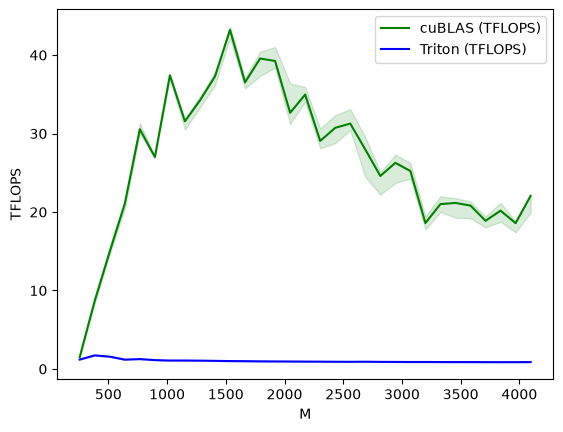

matmul-performance-fp16:
         M       N       K  cuBLAS (TFLOPS)  Triton (TFLOPS)
0    256.0   256.0   256.0         1.510916         1.196322
1    384.0   384.0   384.0         8.695194         1.728000
2    512.0   512.0   512.0        14.952955         1.565915
3    640.0   640.0   640.0        21.072669         1.188495
4    768.0   768.0   768.0        30.557530         1.257844
5    896.0   896.0   896.0        27.017846         1.125744
6   1024.0  1024.0  1024.0        37.428256         1.070949
7   1152.0  1152.0  1152.0        31.566398         1.073600
8   1280.0  1280.0  1280.0        34.222454         1.055007
9   1408.0  1408.0  1408.0        37.289052         1.030533
10  1536.0  1536.0  1536.0        43.207253         1.003284
11  1664.0  1664.0  1664.0        36.525265         0.990565
12  1792.0  1792.0  1792.0        39.562377         0.969023
13  1920.0  1920.0  1920.0        39.251819         0.957322
14  2048.0  2048.0  2048.0        32.649430         0.947355

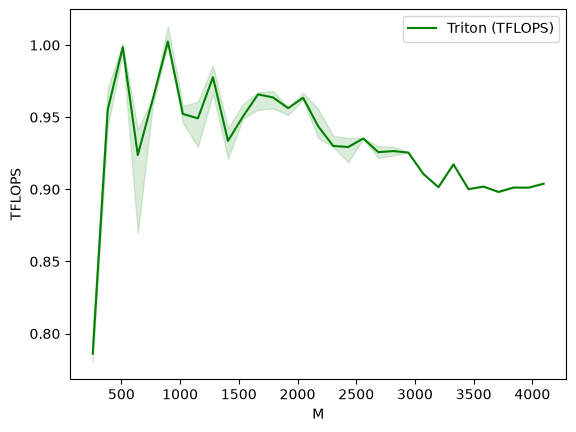

matmul-performance-fp8:
         M       N       K  Triton (TFLOPS)
0    256.0   256.0   256.0         0.786039
1    384.0   384.0   384.0         0.955181
2    512.0   512.0   512.0         0.998584
3    640.0   640.0   640.0         0.923771
4    768.0   768.0   768.0         0.962552
5    896.0   896.0   896.0         1.002479
6   1024.0  1024.0  1024.0         0.952223
7   1152.0  1152.0  1152.0         0.949203
8   1280.0  1280.0  1280.0         0.977755
9   1408.0  1408.0  1408.0         0.933528
10  1536.0  1536.0  1536.0         0.950570
11  1664.0  1664.0  1664.0         0.965795
12  1792.0  1792.0  1792.0         0.963695
13  1920.0  1920.0  1920.0         0.956277
14  2048.0  2048.0  2048.0         0.963438
15  2176.0  2176.0  2176.0         0.943694
16  2304.0  2304.0  2304.0         0.930059
17  2432.0  2432.0  2432.0         0.929308
18  2560.0  2560.0  2560.0         0.935240
19  2688.0  2688.0  2688.0         0.925777
20  2816.0  2816.0  2816.0         0.926499
21  2944

In [12]:
ref_lib = 'cuBLAS' if is_cuda() else 'rocBLAS'


configs = []
for fp8_inputs in [False, True]:
    if fp8_inputs and (not TORCH_HAS_FP8 or not is_cuda()):
        continue
    configs.append(
        triton.testing.Benchmark(
            x_names=["M", "N", "K"],  # Argument names to use as an x-axis for the plot 作为绘图 x 轴的参数名
            x_vals=[128 * i for i in range(2, 33)],  # Different possible values for `x_name` `x_names` 参数的不同可能值
            line_arg="provider",  # Argument name whose value corresponds to a different line in the plot 对应绘图中不同线的参数名
            # Possible values for `line_arg` `line_arg` 的可能值
            # Don't compare to cublas for fp8 cases as torch.matmul doesn't support fp8 at the moment. 在 fp8 情况下不与 cuBLAS 比较，因为 torch.matmul 目前不支持 fp8。
            line_vals=["triton"] if fp8_inputs else [ref_lib.lower(), "triton"],  # Label name for the lines
            line_names=["Triton"] if fp8_inputs else [ref_lib, "Triton"],  # Line styles
            styles=[("green", "-"), ("blue", "-")],
            ylabel="TFLOPS",  # Label name for the y-axis y 轴的标签名称
            plot_name="matmul-performance-" +
            ("fp16" if not fp8_inputs else "fp8"),  # Name for the plot, used also as a file 绘图名称，也用作保存绘图的文件名 name for saving the plot.
            args={"fp8_inputs": fp8_inputs},
        ))




@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider, fp8_inputs):
    a = torch.randn((M, K), device='cuda', dtype=torch.float16)
    b = torch.randn((K, N), device='cuda', dtype=torch.float16)
    if TORCH_HAS_FP8 and fp8_inputs:
        a = a.to(torch.float8_e5m2)
        b = b.T
        b = b.to(torch.float8_e5m2)
    quantiles = [0.5, 0.2, 0.8]
    if provider == ref_lib.lower():
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.matmul(a, b), quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: matmul(a, b), quantiles=quantiles)
    perf = lambda ms: 2 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark.run(show_plots=True, print_data=True)